- compare 16 ccc inference resources and 7 methods, plus consensus between the methods predictions
- the ccc tools typically use gene expression information obtained by scRNA-seq
- single cells are clustered by their gene expression profile and cell type identitities are assigned to clusters based on known gene markers
- then CCC tools can predict intercellular crosstalk between any pair of clusters, one cluster being the source, other the target of a CCC event
- CCC tools estimate likelihood of crosstalk based on expression level of transmitter and receiver in source and target clusters respectiely


prior to combination of methods LIANA analyzed:
- degree of overlap among resources and whether certain resources are biased toward specific biological terms (pathways, tissue-enriched proteins)
- decoupled methods from their corresponding resources and apllied all method-resource combinations on 6 different datasets
- aggregate rank: consensus rank across all methods using Robust Rank Aggregation
    - can be interpreted as probabilisitc distribution for interactions that are preferentially highly-ranked
    - bult across universe of all interaction predictions, after independent filtering by each method
    - LIANA ranks all interactions (each method score is converted into rank)
    - mean rank = average of method ranks
    - missing ranks are replaced by worst observed rank
    - all rnaks are normalized by maximum rank so they become values between 0 and 1

In [2]:
suppressPackageStartupMessages({
  library(Seurat)
  library(liana)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(stringr)
  library(purrr)
  library(ggplot2)
  library(forcats)
  library(circlize)
})

set.seed(123)

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
#file_name <- "gated_our_dataset_processed.rds" 

input_file <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data//datasets/gated_sepsis_processed.rds"
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/liana_split_pla_vs_platelet_free"
plot_dir <- file.path(out_dir, "plots")

dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(plot_dir, recursive = TRUE, showWarnings = FALSE)

message("Output directory: ", out_dir)

Output directory: /nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/v2/liana_split_pla_vs_platelet_free



# 1. Load & prepare data

In [3]:
seurat_obj <- readRDS(input_file)

DefaultAssay(seurat_obj)
ncol(seurat_obj)
nrow(seurat_obj)
colnames(seurat_obj@meta.data)

[1] "RNA"

[1] 285043

[1] 37487

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"

In [4]:
table(seurat_obj$pla_status, useNA = "ifany")
table(seurat_obj$lineage, seurat_obj$pla_status, useNA = "ifany")


          PLA platelet-free 
        39405        245638 

             
                 PLA platelet-free
  DCs           2298          3440
  NK cells      2443         31768
  Unassigned       0        117212
  neutrophils      0          4210
  CD8 T cells   7504         19400
  B cells        488         20788
  CD4 T cells   5680         45049
  Monocytes    20992          3479
  <NA>             0           292

In [5]:
table(is.na(seurat_obj$lineage))

seurat_obj <- subset(
  seurat_obj,
  subset = !is.na(lineage)
)

table(is.na(seurat_obj$lineage))
table(seurat_obj$lineage)


 FALSE   TRUE 
284751    292 

Warning message:
“Removing 292 cells missing data for vars requested”



 FALSE 
284751 


        DCs    NK cells  Unassigned neutrophils CD8 T cells     B cells 
       5738       34211      117212        4210       26904       21276 
CD4 T cells   Monocytes 
      50729       24471 

# 2. Split into PLA & platelet-free subsets

In [6]:
seurat_pla <- seurat_obj[,seurat_obj$pla_status == 'PLA']
seurat_pf <- seurat_obj[,seurat_obj$pla_status == 'platelet-free']

head(seurat_pla)
head(seurat_pf)


# LIANA should infer communication between lineages, so identities are lineage
Idents(seurat_pla) <- "lineage"
Idents(seurat_pf)  <- "lineage"

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,sample,donor_id,cell_barcodes,scRNA.seq,TCR,⋯,seurat_clusters,RNA_snn_res.0.25,RNA.weight,ADT.weight,leiden_0.8_totalVI,leiden_0.25_totalVI,celltype_full,lineage,pla_status,celltype
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<fct>,<chr>,<chr>
GSM8571042_Abd-S111_AAACCTGGTGACTACT-1,GSM8571042_Abd-S111,3711,1622,788,148,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTGACTACT-1,1,1,⋯,2,2,6.303203e-01,0.3696797,2,1,pla CD8 T cells,CD8 T cells,PLA,CD8 T cells
GSM8571042_Abd-S111_AAACCTGTCATCTGTT-1,GSM8571042_Abd-S111,1428,584,835,165,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGTCATCTGTT-1,1,1,⋯,1,1,9.259400e-06,0.9999907,5,2,pla cd4 t cells,CD4 T cells,PLA,CD4 T cells
GSM8571042_Abd-S111_AAAGATGAGCACCGCT-1,GSM8571042_Abd-S111,8590,2358,1080,163,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAAGATGAGCACCGCT-1,1,1,⋯,0,0,5.751946e-01,0.4248054,1,0,pla monocytes,Monocytes,PLA,Monocytes
GSM8571042_Abd-S111_AAAGATGAGGGCTCTC-1,GSM8571042_Abd-S111,5295,1734,693,155,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAAGATGAGGGCTCTC-1,1,1,⋯,0,0,7.646664e-01,0.2353336,1,0,pla monocytes,Monocytes,PLA,Monocytes
GSM8571042_Abd-S111_AAAGCAAGTCAGCTAT-1,GSM8571042_Abd-S111,3037,1260,678,144,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAAGCAAGTCAGCTAT-1,1,1,⋯,1,1,3.699107e-01,0.6300893,12,2,pla cd4 t cells,CD4 T cells,PLA,CD4 T cells
GSM8571042_Abd-S111_AAAGCAAGTGCTCTTC-1,GSM8571042_Abd-S111,3770,1296,2120,162,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAAGCAAGTGCTCTTC-1,1,1,⋯,1,1,5.423335e-05,0.9999458,4,2,pla cd4 t cells,CD4 T cells,PLA,CD4 T cells
GSM8571042_Abd-S111_AAAGTAGCAGCTGTTA-1,GSM8571042_Abd-S111,7310,2104,914,161,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAAGTAGCAGCTGTTA-1,1,1,⋯,0,0,7.656687e-01,0.2343313,1,0,pla early nk cells,NK cells,PLA,Early NK cells
GSM8571042_Abd-S111_AAAGTAGGTAATCACC-1,GSM8571042_Abd-S111,6362,1952,1393,166,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAAGTAGGTAATCACC-1,1,1,⋯,0,0,9.777077e-02,0.9022292,1,0,ppla classical monocytes,Monocytes,PLA,Classical monocytes
GSM8571042_Abd-S111_AAATGCCGTCCGACGT-1,GSM8571042_Abd-S111,4034,1560,620,149,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAATGCCGTCCGACGT-1,1,1,⋯,2,2,3.553816e-01,0.6446184,2,1,pla CD8 T cells,CD8 T cells,PLA,CD8 T cells


,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,sample,donor_id,cell_barcodes,scRNA.seq,TCR,⋯,seurat_clusters,RNA_snn_res.0.25,RNA.weight,ADT.weight,leiden_0.8_totalVI,leiden_0.25_totalVI,celltype_full,lineage,pla_status,celltype
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<fct>,<chr>,<chr>
GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1,GSM8571042_Abd-S111,2613,1041,1050,160,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1,1,1,⋯,0,0,0.97098270,0.0290173,0,0,non-T cell/ non NK cell,Unassigned,platelet-free,Non-T / non-NK cells
GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1,GSM8571042_Abd-S111,5223,1471,1021,159,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1,1,1,⋯,0,0,0.08052634,0.9194737,1,0,neutrophils,neutrophils,platelet-free,Neutrophils
GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1,GSM8571042_Abd-S111,4243,1395,396,113,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1,1,1,⋯,1,1,0.28554898,0.7144510,4,2,R11,Unassigned,platelet-free,Unassigned (R11)
GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1,GSM8571042_Abd-S111,5729,1994,985,160,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1,1,1,⋯,0,0,0.83490856,0.1650914,0,0,non-T cell/ non NK cell,Unassigned,platelet-free,Non-T / non-NK cells
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,GSM8571042_Abd-S111,7899,2114,772,140,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1,1,1,⋯,4,4,0.73354394,0.2664561,9,3,platelet free B cells,B cells,platelet-free,B cells
GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,GSM8571042_Abd-S111,5756,1892,404,114,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTACGAAAT-1,1,1,⋯,2,2,0.59590352,0.4040965,2,1,platelet free cd4 t cells,CD4 T cells,platelet-free,CD4 T cells
GSM8571042_Abd-S111_AAACCTGGTATAGGGC-1,GSM8571042_Abd-S111,3080,1419,598,141,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTATAGGGC-1,1,1,⋯,0,0,0.21371779,0.7862822,0,0,non-T cell/ non NK cell,Unassigned,platelet-free,Non-T / non-NK cells
GSM8571042_Abd-S111_AAACCTGGTGCCTGCA-1,GSM8571042_Abd-S111,7506,2276,1276,168,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGGTGCCTGCA-1,1,1,⋯,0,0,0.51350908,0.4864909,0,0,non B cell/non T cell/ non monocyte,Unassigned,platelet-free,Non-B / Non-T / Non-monocyte cells
GSM8571042_Abd-S111_AAACCTGTCAACTCTT-1,GSM8571042_Abd-S111,4290,1572,379,109,GSM8571042_Abd-S111,Abd-S111,GSM8571042_Abd-S111_AAACCTGTCAACTCTT-1,1,1,⋯,1,1,0.52105465,0.4789454,4,2,platelet free cd4 t cells,CD4 T cells,platelet-free,CD4 T cells


# 3. Perform LIANA analysis

In [7]:
liana_pla_raw <- liana_wrap(seurat_pla)

liana_pla <- liana_pla_raw %>%
  liana_aggregate() %>%
  arrange(aggregate_rank)

Expression from the `RNA` assay will be used



Running LIANA with `lineage` as labels!

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the liana package.
  Please report the issue at <https://github.com/saezlab/liana/issues>.”
Warning message in exec(output, ...):
“12546 genes and/or 0 cells were removed as they had no counts!”
Warning message:
“`invoke()` is deprecated as of rlang 0.4.0.
Please use `exec()` or `inject()` instead.
This warning is displayed once every 8 hours.”
LIANA: LR summary stats calculated!

Now Running: Natmi

Now Running: Connectome

Now Running: Logfc

Now Running: Sca

Now Running: Cellphonedb

Warning message:
“`progress_estimated()` was deprecated in dplyr 1.0.0.
ℹ The deprecated feature was likely used in the liana package.
  Please report the issue at <https://github.com/saezlab/liana/issues>.”
Now aggregating natmi

Now aggregating connectome

Now aggregating logfc


In [ ]:
str(liana_pla)

tibble [6,966 × 16] (S3: tbl_df/tbl/data.frame)
 $ source                : chr [1:6966] "B cells" "CD8 T cells" "CD8 T cells" "CD8 T cells" ...
 $ target                : chr [1:6966] "B cells" "CD8 T cells" "CD8 T cells" "CD8 T cells" ...
 $ ligand.complex        : chr [1:6966] "BTLA" "HLA-C" "HLA-B" "HLA-A" ...
 $ receptor.complex      : chr [1:6966] "CD79A" "CD8B" "CD8B" "CD8B" ...
 $ aggregate_rank        : num [1:6966] 5.07e-08 9.68e-07 1.43e-06 1.59e-06 1.65e-06 ...
 $ mean_rank             : num [1:6966] 1147 424 416 425 434 ...
 $ natmi.edge_specificity: num [1:6966] 0.685 0.179 0.174 0.181 0.173 ...
 $ natmi.rank            : num [1:6966] 1 98 108 94 112 118 121 102 127 131 ...
 $ connectome.weight_sc  : num [1:6966] 3.39 1.21 1.26 1.22 1.11 ...
 $ connectome.rank       : num [1:6966] 1 54 45 52 70 43 58 61 46 51 ...
 $ logfc.logfc_comb      : num [1:6966] 2.05 1.77 1.79 1.8 1.73 ...
 $ logfc.rank            : num [1:6966] 7 32 27 25 39 17 35 29 21 20 ...
 $ sca.LRscore       

In [8]:
liana_pf_raw <- liana_wrap(seurat_pf)

liana_pf <- liana_pf_raw %>%
  liana_aggregate() %>%
  arrange(aggregate_rank)

Expression from the `RNA` assay will be used

Running LIANA with `lineage` as labels!

Warning message in exec(output, ...):
“8889 genes and/or 0 cells were removed as they had no counts!”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.1 GiB”
LIANA: LR summary stats calculated!

Now Running: Natmi

Now Running: Connectome

Now Running: Logfc

Now Running: Sca

Now Running: Cellphonedb

Now aggregating natmi

Now aggregating connectome

Now aggregating logfc

Now aggregating sca

Now aggregating cellphonedb

Aggregating Ranks



In [14]:
str(liana_pf)

tibble [10,235 × 16] (S3: tbl_df/tbl/data.frame)
 $ source                : chr [1:10235] "B cells" "NK cells" "CD8 T cells" "NK cells" ...
 $ target                : chr [1:10235] "B cells" "CD8 T cells" "CD8 T cells" "CD8 T cells" ...
 $ ligand.complex        : chr [1:10235] "BTLA" "HLA-A" "HLA-A" "HLA-C" ...
 $ receptor.complex      : chr [1:10235] "CD79A" "CD8B" "CD8B" "CD8B" ...
 $ aggregate_rank        : num [1:10235] 3.73e-10 9.42e-07 1.47e-06 1.55e-06 1.97e-06 ...
 $ mean_rank             : num [1:10235] 1127 764 787 765 779 ...
 $ natmi.edge_specificity: num [1:10235] 0.63 0.121 0.118 0.117 0.116 ...
 $ natmi.rank            : num [1:10235] 2 143 160 162 172 177 179 195 212 220 ...
 $ connectome.weight_sc  : num [1:10235] 1.99 1.39 1.34 1.4 1.38 ...
 $ connectome.rank       : num [1:10235] 1 8 18 7 11 5 6 17 15 19 ...
 $ logfc.logfc_comb      : num [1:10235] 2.32 1.54 1.4 1.53 1.42 ...
 $ logfc.rank            : num [1:10235] 1 85 156 89 140 133 101 132 138 204 ...
 $ sca.LRsc

In [9]:
head(liana_pla)
head(liana_pf)

source,target,ligand.complex,receptor.complex,aggregate_rank,mean_rank,natmi.edge_specificity,natmi.rank,connectome.weight_sc,connectome.rank,logfc.logfc_comb,logfc.rank,sca.LRscore,sca.rank,cellphonedb.pvalue,cellphonedb.rank
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B cells,B cells,BTLA,CD79A,5.065926e-08,1147.0,0.6853260,1,3.386299,1,2.054045,7,0.8285400,3882,0,1844
CD8 T cells,CD8 T cells,HLA-C,CD8B,9.682664e-07,424.0,0.1793405,98,1.205794,54,1.771482,32,0.9603332,92,0,1844
CD8 T cells,CD8 T cells,HLA-B,CD8B,1.426530e-06,415.6,0.1741327,108,1.264300,45,1.791882,27,0.9630298,54,0,1844
CD8 T cells,CD8 T cells,HLA-A,CD8B,1.591205e-06,425.2,0.1811665,94,1.215290,52,1.803879,25,0.9594236,111,0,1844
NK cells,CD8 T cells,HLA-C,CD8B,1.649134e-06,434.4,0.1725574,112,1.112551,70,1.730570,39,0.9595922,107,0,1844
CD8 T cells,CD8 T cells,HLA-A,CD8A,2.030526e-06,418.0,0.1698828,118,1.270755,43,1.864155,17,0.9623341,68,0,1844


source,target,ligand.complex,receptor.complex,aggregate_rank,mean_rank,natmi.edge_specificity,natmi.rank,connectome.weight_sc,connectome.rank,logfc.logfc_comb,logfc.rank,sca.LRscore,sca.rank,cellphonedb.pvalue,cellphonedb.rank
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B cells,B cells,BTLA,CD79A,3.729659e-10,1126.6,0.6298253,2,1.989211,1,2.321846,1,0.9267008,2181,0,3448
NK cells,CD8 T cells,HLA-A,CD8B,9.420006e-07,764.4,0.1205218,143,1.391341,8,1.544366,85,0.9668486,138,0,3448
CD8 T cells,CD8 T cells,HLA-A,CD8B,1.474358e-06,787.4,0.1175261,160,1.342147,18,1.397580,156,0.9664428,155,0,3448
NK cells,CD8 T cells,HLA-C,CD8B,1.549224e-06,764.8,0.1174339,162,1.398701,7,1.531782,89,0.9676324,118,0,3448
CD8 T cells,CD8 T cells,HLA-C,CD8B,1.967090e-06,779.4,0.1162236,172,1.376093,11,1.422873,140,0.9674698,126,0,3448
CD8 T cells,CD8 T cells,HLA-B,CD8B,2.205115e-06,766.2,0.1146763,177,1.427352,5,1.437977,133,0.9700785,68,0,3448


# 4. Plots

Comparison table 
- aggregate rank: LIANA consensus rank across methods
    - lower = better/stronger/more consistently supported
- mean rank: average rank across methods
    - lower = better
- sca.LRScore = expression magnitude score
    - higher = stronger lr expression
- natmi.edge_specificity = how specific interaction is to that source-target pair
    - higher = more specific

In [10]:
liana_pla_plot <- liana_pla %>%
  as_tibble() %>%
  transmute(
    source,
    target,
    ligand = ligand.complex,
    receptor = receptor.complex,
    aggregate_rank_PLA = aggregate_rank,
    mean_rank_PLA = mean_rank,
    LRscore_PLA = sca.LRscore,
    specificity_PLA = natmi.edge_specificity
  )

liana_pf_plot <- liana_pf %>%
  as_tibble() %>%
  transmute(
    source,
    target,
    ligand = ligand.complex,
    receptor = receptor.complex,
    aggregate_rank_pf = aggregate_rank,
    mean_rank_pf = mean_rank,
    LRscore_pf = sca.LRscore,
    specificity_pf = natmi.edge_specificity
  )

In [11]:
liana_split <- full_join(
  liana_pla_plot,
  liana_pf_plot,
  by = c("source", "target", "ligand", "receptor")
) %>%
  mutate(
    interaction = paste(ligand, receptor, sep = " → "),
    lineage_pair = paste(source, target, sep = " → ")
  )

In [12]:
str(liana_split)

tibble [12,157 × 14] (S3: tbl_df/tbl/data.frame)
 $ source            : chr [1:12157] "B cells" "CD8 T cells" "CD8 T cells" "CD8 T cells" ...
 $ target            : chr [1:12157] "B cells" "CD8 T cells" "CD8 T cells" "CD8 T cells" ...
 $ ligand            : chr [1:12157] "BTLA" "HLA-C" "HLA-B" "HLA-A" ...
 $ receptor          : chr [1:12157] "CD79A" "CD8B" "CD8B" "CD8B" ...
 $ aggregate_rank_PLA: num [1:12157] 5.07e-08 9.68e-07 1.43e-06 1.59e-06 1.65e-06 ...
 $ mean_rank_PLA     : num [1:12157] 1147 424 416 425 434 ...
 $ LRscore_PLA       : num [1:12157] 0.829 0.96 0.963 0.959 0.96 ...
 $ specificity_PLA   : num [1:12157] 0.685 0.179 0.174 0.181 0.173 ...
 $ aggregate_rank_pf : num [1:12157] 3.73e-10 1.97e-06 2.21e-06 1.47e-06 1.55e-06 ...
 $ mean_rank_pf      : num [1:12157] 1127 779 766 787 765 ...
 $ LRscore_pf        : num [1:12157] 0.927 0.967 0.97 0.966 0.968 ...
 $ specificity_pf    : num [1:12157] 0.63 0.116 0.115 0.118 0.117 ...
 $ interaction       : chr [1:12157] "BTLA → CD

We dont have any statistical scores, so we could set a significance threshold for aggregate-rank?

In [24]:
thresholds <- c(0.001, 0.005, 0.01, 0.05, 0.1)

threshold_summary <- lapply(thresholds, function(rank_threshold) {
  
  liana_split %>%
    mutate(
      detected_PLA = !is.na(aggregate_rank_PLA) & aggregate_rank_PLA < rank_threshold,
      detected_pf  = !is.na(aggregate_rank_pf) & aggregate_rank_pf < rank_threshold,
      
      direction = case_when(
        detected_PLA & !detected_pf ~ "PLA-only",
        !detected_PLA & detected_pf ~ "platelet-free-only",
        detected_PLA & detected_pf  ~ "shared",
        TRUE ~ "not detected"
      )
    ) %>%
    filter(direction != "not detected") %>%
    count(direction) %>%
    mutate(rank_threshold = rank_threshold)
  
}) %>%
  bind_rows()

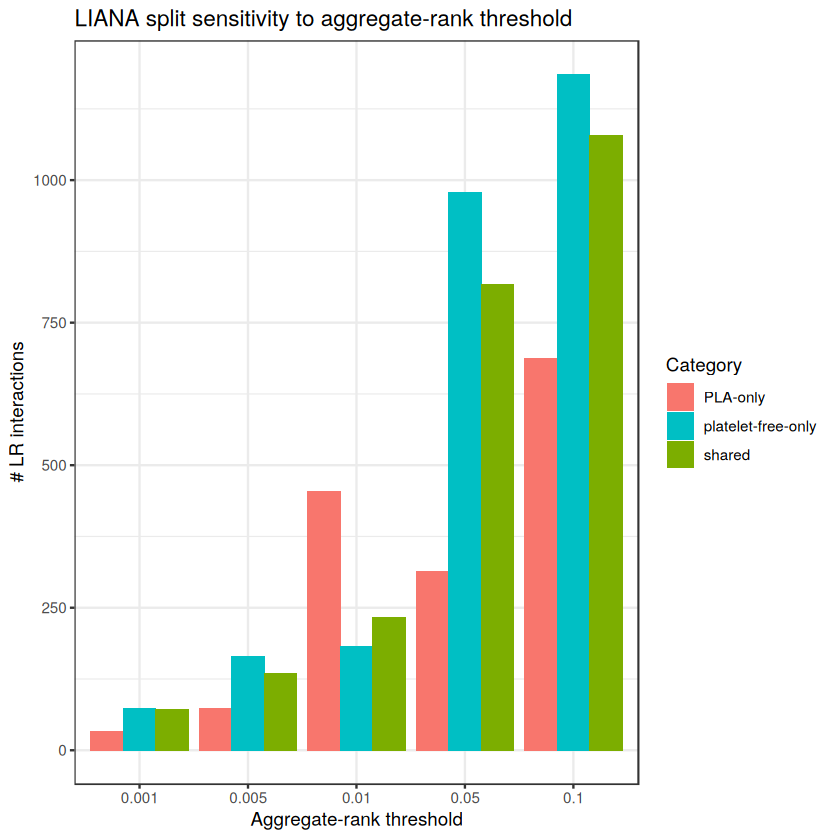

In [25]:
ggplot(
  threshold_summary,
  aes(
    x = factor(rank_threshold),
    y = n,
    fill = direction
  )
) +
  geom_col(position = "dodge") +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-only" = "#F8766D",
      "platelet-free-only" = "#00BFC4",
      "shared" = "#7CAE00"
    )
  ) +
  labs(
    title = "LIANA split sensitivity to aggregate-rank threshold",
    x = "Aggregate-rank threshold",
    y = "# LR interactions",
    fill = "Category"
  )

In [26]:
rank_threshold <- 0.05

In [27]:
liana_split_thresh <- liana_split %>%
  mutate(
    detected_PLA = !is.na(aggregate_rank_PLA) & aggregate_rank_PLA < rank_threshold,
    detected_pf  = !is.na(aggregate_rank_pf) & aggregate_rank_pf < rank_threshold,
    
    direction = case_when(
      detected_PLA & !detected_pf ~ "PLA-only",
      !detected_PLA & detected_pf ~ "platelet-free-only",
      detected_PLA & detected_pf  ~ "shared",
      TRUE ~ "not detected"
    )
  ) %>%
  filter(direction != "not detected")

### 1. Global distribution plot

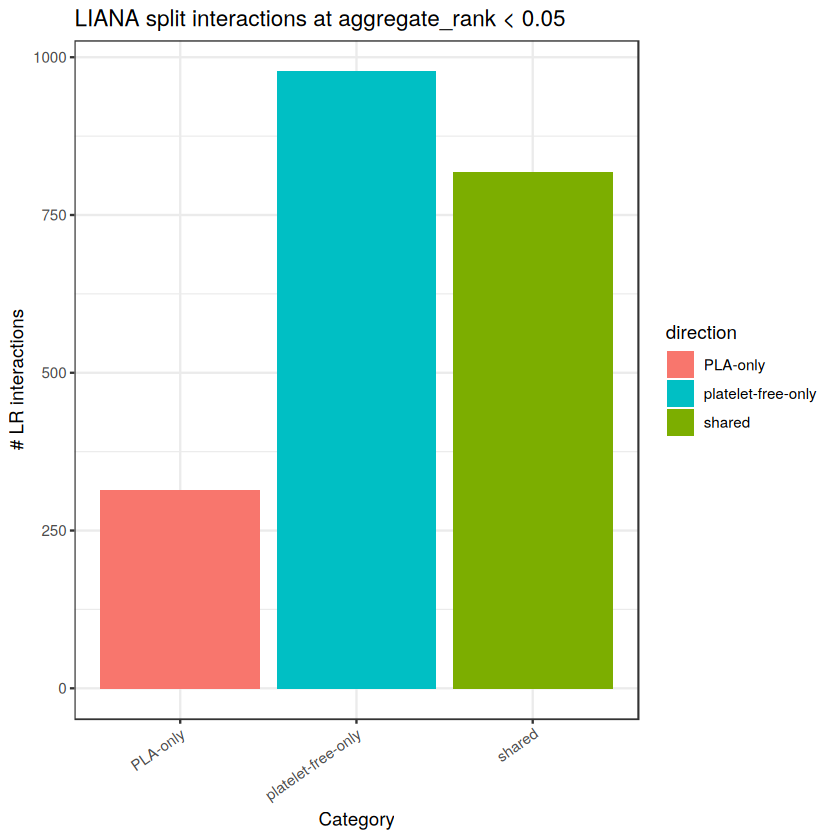

In [28]:
ggplot(liana_split_thresh, aes(x = direction, fill = direction)) +
  geom_bar() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-only" = "#F8766D",
      "platelet-free-only" = "#00BFC4",
      "shared" = "#7CAE00"
    )
  ) +
  labs(
    title = paste0("LIANA split interactions at aggregate_rank < ", rank_threshold),
    x = "Category",
    y = "# LR interactions"
  ) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

### 2. Direction by lineage pair

- counts how many interactions each lineage pair has in each category
- e.g. lineage pair Monocytes -> B cells, direction PLA-only, n = 12
- calculates total number of condition-specific interactions per lineage pair (lineage pair, pla-only + platelet-only)
- keeps top 25

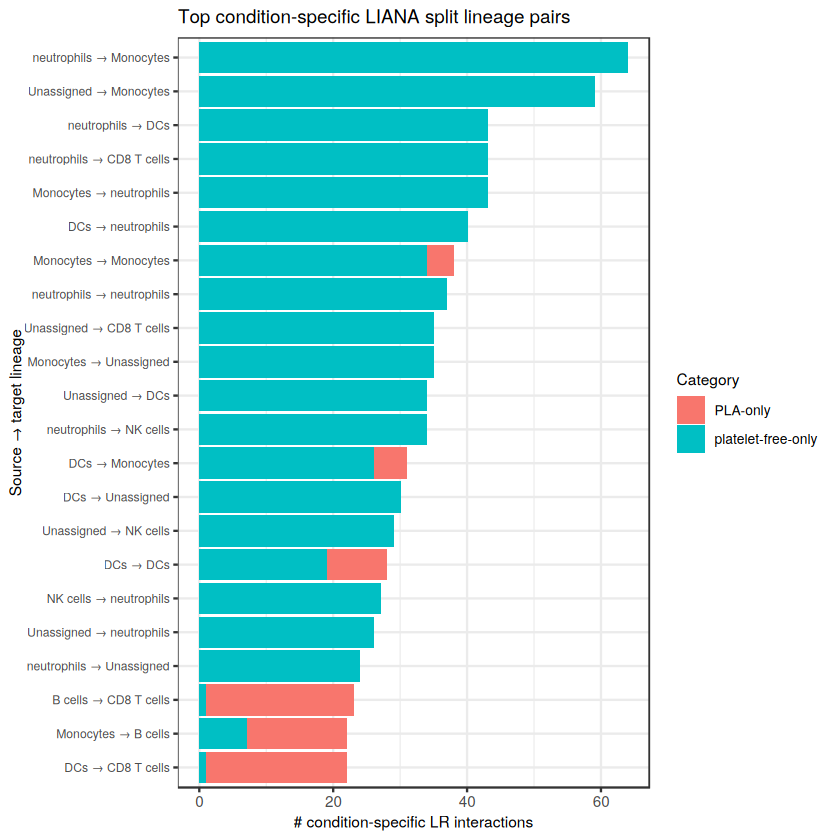

In [38]:
pair_counts_liana_split_specific <- liana_split_thresh %>%
  filter(direction != "shared") %>%
  count(lineage_pair, direction) %>%
  group_by(lineage_pair) %>%
  mutate(total = sum(n)) %>%
  ungroup() %>%
  slice_max(total, n = 25) %>%
  mutate(lineage_pair = fct_reorder(lineage_pair, total))

ggplot(pair_counts_liana_split_specific, aes(x = n, y = lineage_pair, fill = direction)) +
  geom_col() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-only" = "#F8766D",
      "platelet-free-only" = "#00BFC4"
    )
  ) +
  labs(
    title = "Top condition-specific LIANA split lineage pairs",
    x = "# condition-specific LR interactions",
    y = "Source → target lineage",
    fill = "Category"
  ) +
  theme(
    axis.text.y = element_text(size = 7),
    axis.title = element_text(size = 9),
    plot.title = element_text(size = 11),
    legend.title = element_text(size = 9),
    legend.text = element_text(size = 8)
  )

### 3. Net direction heatmap

- e.g. source monocytes, target b cells, pla-only 20, platelet-free only 5, net = 15
- fill missing categories with 0

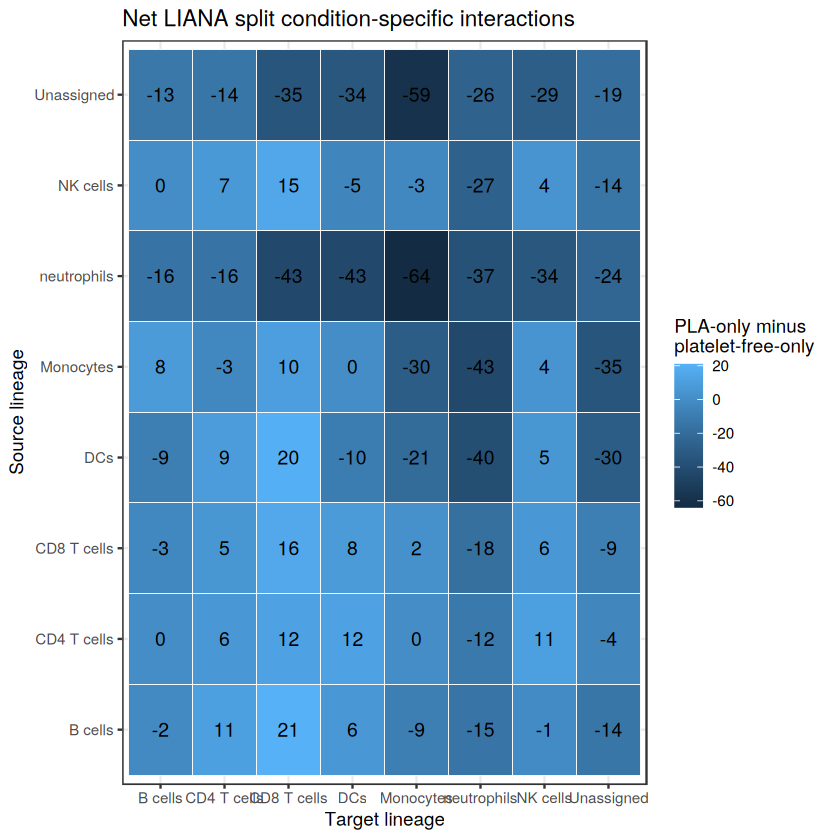

In [30]:
net_direction_liana_split <- liana_split_thresh %>%
  filter(direction != "shared") %>%
  count(source, target, direction) %>%
  complete(
    source,
    target,
    direction = c("PLA-only", "platelet-free-only"),
    fill = list(n = 0)
  ) %>%
  pivot_wider(
    names_from = direction,
    values_from = n,
    values_fill = 0
  ) %>%
  mutate(
    net = `PLA-only` - `platelet-free-only`
  )

ggplot(net_direction_liana_split, aes(x = target, y = source, fill = net)) +
  geom_tile(color = "white") +
  geom_text(aes(label = net), size = 4) +
  theme_bw() +
  labs(
    title = "Net LIANA split condition-specific interactions",
    x = "Target lineage",
    y = "Source lineage",
    fill = "PLA-only minus\nplatelet-free-only"
  )

### 4. Most recurrent LR pairs

- n_lineage_pairs counts how often the same LR pair appears
- total sums across directions for same LR pair

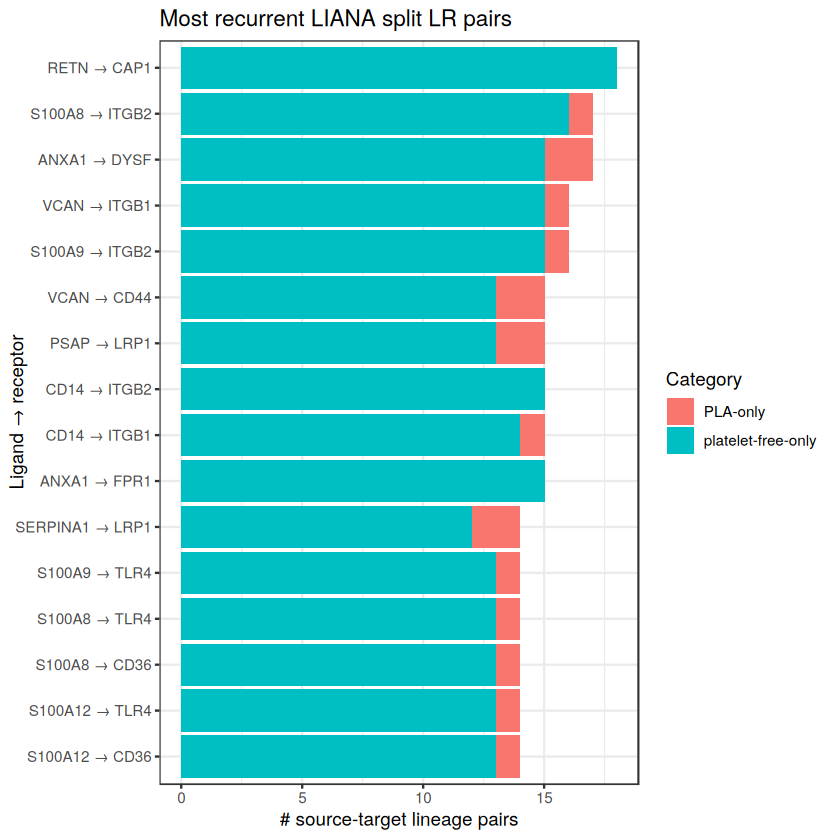

In [41]:
top_recurrent_liana_split <- liana_split_thresh %>%
  filter(direction != "shared") %>%
  count(interaction, direction, name = "n_lineage_pairs") %>%
  group_by(interaction) %>%
  mutate(total = sum(n_lineage_pairs)) %>%
  ungroup() %>%
  slice_max(total, n = 25) %>%
  mutate(interaction = fct_reorder(interaction, total)) # order by recurrence

ggplot(top_recurrent_liana_split, aes(x = n_lineage_pairs, y = interaction, fill = direction)) +
  geom_col() +
  theme_bw() +
  scale_fill_manual(
    values = c(
      "PLA-only" = "#F8766D",
      "platelet-free-only" = "#00BFC4"
      #"shared" = "#7CAE00"
    )
  ) +
  labs(
    title = "Most recurrent LIANA split LR pairs",
    x = "# source-target lineage pairs",
    y = "Ligand → receptor",
    fill = "Category"
  )

### 5. Top Interations per lineage pair

- take better aggregate rank between PLA and platelet-free
- turn small ranks into large scores with -log10
- keep top 3 strongest lr interactions per lineage pair

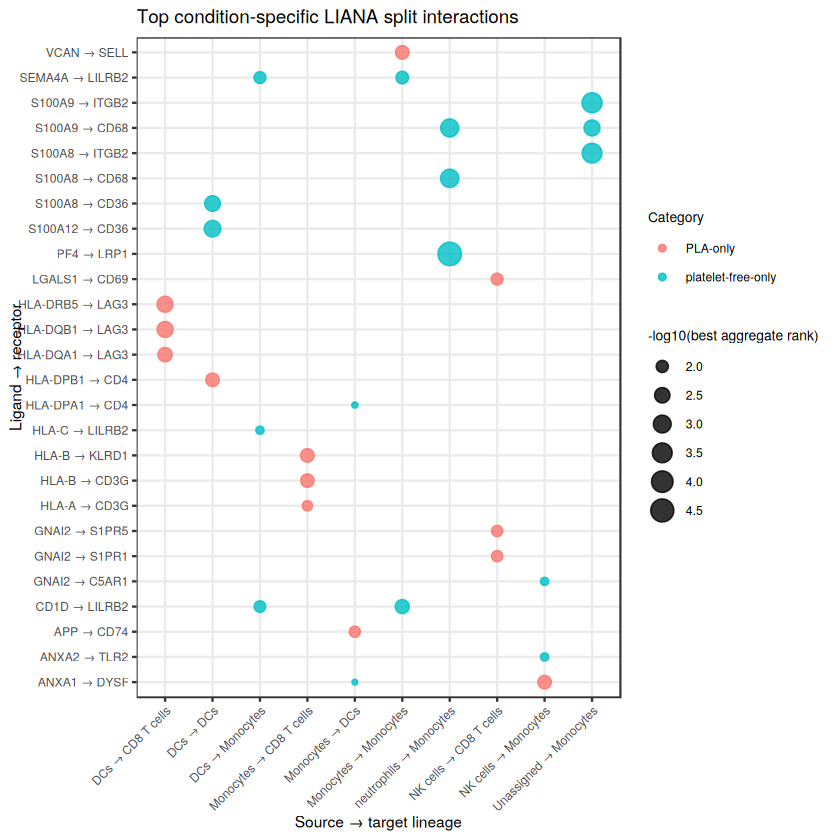

In [40]:
top_liana_split_per_pair_specific <- liana_split_thresh %>%
  filter(direction != "shared") %>%
  filter(lineage_pair %in% top_lineage_pairs) %>%
  mutate(
    best_rank = pmin(
      aggregate_rank_PLA,
      aggregate_rank_pf,
      na.rm = TRUE
    ),
    rank_score = -log10(best_rank + 1e-300)
  ) %>%
  group_by(lineage_pair) %>%
  slice_max(rank_score, n = 3, with_ties = FALSE) %>%
  ungroup()

ggplot(
  top_liana_split_per_pair_specific,
  aes(
    x = lineage_pair,
    y = interaction,
    size = rank_score,
    color = direction
  )
) +
  geom_point(alpha = 0.8) +
  theme_bw() +
  scale_color_manual(
    values = c(
      "PLA-only" = "#F8766D",
      "platelet-free-only" = "#00BFC4"
    )
  ) +
  labs(
    title = "Top condition-specific LIANA split interactions",
    x = "Source → target lineage",
    y = "Ligand → receptor",
    size = "-log10(best aggregate rank)",
    color = "Category"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
    axis.text.y = element_text(size = 7),
    axis.title = element_text(size = 9),
    plot.title = element_text(size = 11),
    legend.title = element_text(size = 8),
    legend.text = element_text(size = 7)
  )